# Exploratory Data Analysis — Reducing Traffic Mortality Using ML

Covers SRS section 2.2 "Exploratory Data Analysis (EDA)" and synopsis section 7.3.
Uses the cleaned dataset produced by `src/data/preprocess.py` (run `python main.py`
from the project root first if `data/processed/accidents_clean.csv` doesn't exist yet).

This notebook only *looks* at the data — no model training here. Model training
lives in `main.py` / `src/models/`, so this stays reproducible and fast to re-run.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config
from src.features.feature_engineering import add_derived_features

sns.set_style("whitegrid")
df = pd.read_csv(config.DATA_PROCESSED_PATH, parse_dates=["date"])
df = add_derived_features(df)
df.shape

(20000, 20)

## 1. Severity class distribution
Fatal accidents are a small minority — this is *why* the project treats recall on the Fatal class as the primary metric instead of accuracy (see docs/PROJECT_OVERVIEW.md).

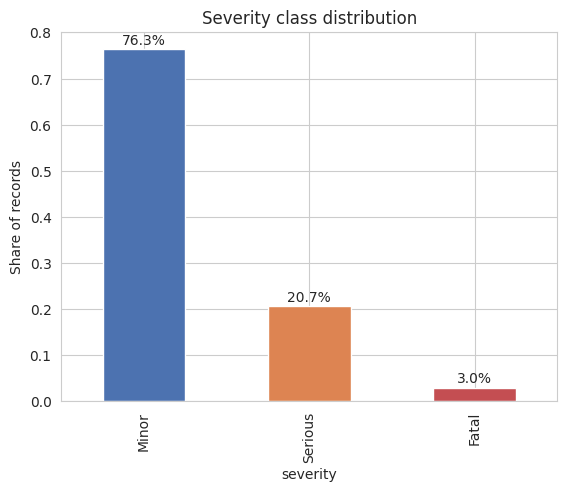

severity
Minor      0.7631
Serious    0.2068
Fatal      0.0301
Name: proportion, dtype: float64

In [2]:
counts = df["severity"].value_counts(normalize=True).reindex(config.SEVERITY_CLASSES)
ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_ylabel("Share of records")
ax.set_title("Severity class distribution")
for i, v in enumerate(counts):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()
counts

## 2. Accidents by hour of day
Accidents cluster around morning/evening rush hours and late night — this is the pattern the `is_rush_hour` and `hour_bucket` engineered features are meant to capture.

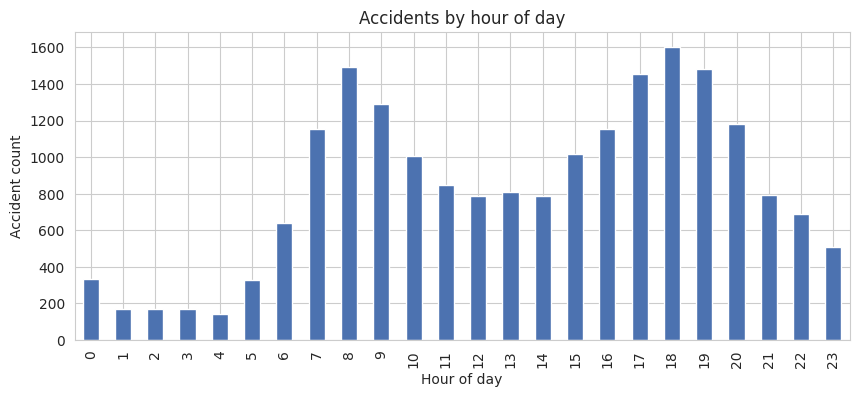

In [3]:
hourly = df.groupby("hour").size()
ax = hourly.plot(kind="bar", figsize=(10, 4), color="#4C72B0")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Accident count")
ax.set_title("Accidents by hour of day")
plt.show()

## 3. Fatal-rate by weather and light condition
Foggy weather and unlit dark roads carry a visibly higher fatal rate than clear/daylight conditions — the signal the severity model's `weather_severity_index` feature is built to summarise.

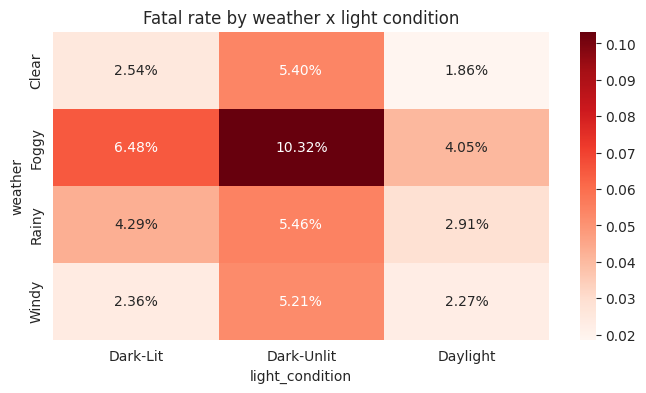

In [4]:
fatal_rate = (
    df.assign(is_fatal=(df["severity"] == "Fatal").astype(int))
      .groupby(["weather", "light_condition"], observed=True)["is_fatal"]
      .mean()
      .unstack()
)
plt.figure(figsize=(8, 4))
sns.heatmap(fatal_rate, annot=True, fmt=".2%", cmap="Reds")
plt.title("Fatal rate by weather x light condition")
plt.show()

## 4. Speed limit vs severity
Higher speed limits (national/state highways) shift the severity mix toward Serious/Fatal, consistent with the MoRTH finding that highways account for a disproportionate share of fatalities despite being a small fraction of road length.

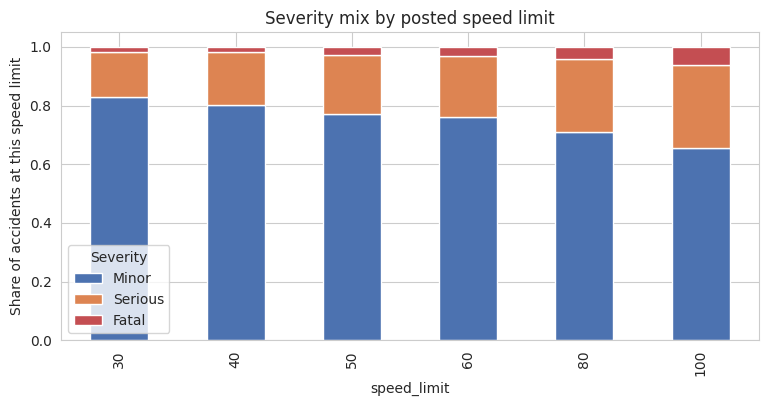

In [5]:
severity_by_speed = pd.crosstab(df["speed_limit"], df["severity"], normalize="index")[config.SEVERITY_CLASSES]
severity_by_speed.plot(kind="bar", stacked=True, figsize=(9, 4),
                       color=["#4C72B0", "#DD8452", "#C44E52"])
plt.ylabel("Share of accidents at this speed limit")
plt.title("Severity mix by posted speed limit")
plt.legend(title="Severity")
plt.show()

## 5. Spatial spread of accidents (quick look)
A full spatial analysis (K-Means / DBSCAN / KDE black-spot ranking) lives in `src/hotspot/hotspot_detection.py` and the dashboard's Hotspot Map tab — this is just a quick scatter to sanity-check the synthetic coordinates before that step runs.

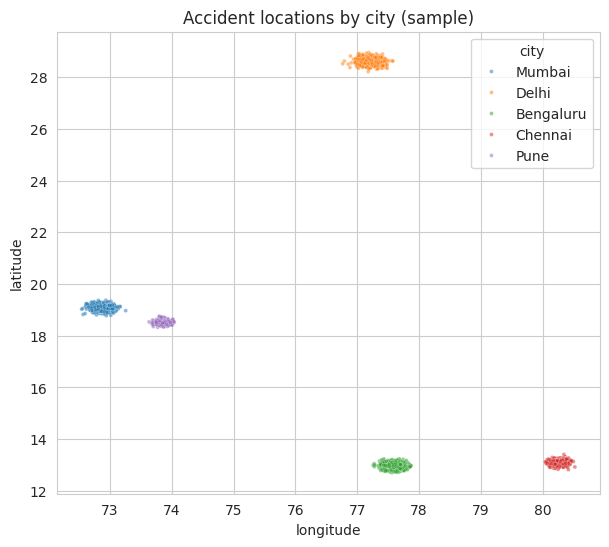

In [6]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df.sample(min(4000, len(df)), random_state=42),
                 x="longitude", y="latitude", hue="city", s=8, alpha=0.5, legend="brief")
plt.title("Accident locations by city (sample)")
plt.show()

## Takeaways feeding into modelling choices

- Fatal is ~2-3% of records -> SMOTE + recall-first evaluation (`src/models/severity_model.py`).
- Hour-of-day and light condition are visibly informative -> engineered as
  `hour_bucket`, `is_rush_hour`, `is_night` (`src/features/feature_engineering.py`).
- Weather and road surface compound each other -> combined into a single
  `weather_severity_index` rather than left as separate categorical columns.
- Accidents are spatially clustered, not uniform -> justifies a dedicated
  hotspot-detection pillar rather than folding location into the severity model alone.